In [ ]:
import torch

def pendulum_dynamics(t, state, beta = 0.4, omega_0 = 9.81/2):
    '''
    arguments:
        state = (theta, omega) - current pendulum angle (or angular displacement) and angular velocity of the pendulum
        beta - damping coefficient
        omega_0 - natural frequency of the pendulum (or natural angular frequency)
    
    returns:
        (dtheta_dt, domega_dt)
    '''
    theta, omega = state

    domega_dt = -2*beta*omega-omega_0**2*torch.sin(theta)
    dtheta_dt = omega

    return torch.tensor([dtheta_dt, domega_dt])


torch.Size([3, 100, 2])


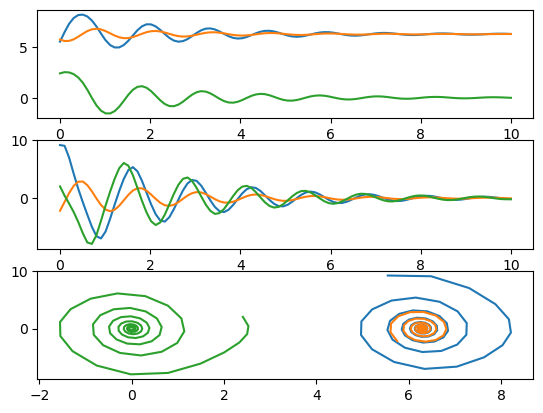

In [7]:
from torchdiffeq import odeint
from matplotlib import pyplot as plt

NUM_TRAJECTORIES = 3
T = 10
CHUNK_LEN = 2
dt = 0.1

torch.manual_seed(42)
y_0s = torch.rand((2, NUM_TRAJECTORIES))
y_0s[0, :] *= 2*torch.pi
y_0s[1, :] -= 1/2
y_0s[1, :] *= 20
chunk_steps = int(CHUNK_LEN / dt)
num_chunks = int(T / CHUNK_LEN)
ts = torch.linspace(0, T, int(T/dt))


trajectories_list = []


for i in range(NUM_TRAJECTORIES):
    trajectory = odeint(pendulum_dynamics, y_0s[:, i], ts)
    trajectories_list.append(trajectory)


fig, axs = plt.subplots(3)
for trajectory in trajectories_list:
    thetas, omegas = trajectory[:, 0].tolist(), trajectory[:, 1].tolist()
    axs[0].plot(ts, thetas)
    axs[1].plot(ts, omegas)
    axs[2].plot(thetas, omegas)

trajectories = torch.stack(trajectories_list)
print(trajectories.shape)

In [8]:
import torch.nn as nn
from torchdiffeq import odeint_adjoint

class ODEFunc(nn.Module):
    """Neural network that parameterizes dy/dt = f(y, t)."""

    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2),
        )

    def forward(self, ts, y):
        return self.net(y)

In [9]:
class NeuralODE(nn.Module):
    """Wraps ODEFunc and solves it with torchdiffeq (Tsit5 solver)."""

    def __init__(self, odefun):
        super(NeuralODE, self).__init__()
        self.odefun = odefun
    
    def forward(self, y0, ts):
        res = odeint_adjoint(self.odefun, y0, ts)
        return res

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
print(f"device: {device}")

ode_func = ODEFunc()
model = NeuralODE(ode_func).to(device)

# Data
y_0s = y_0s.T.to(device)
ts = ts.to(device)
trajectories = trajectories.to(device)

chunked_trajectories = trajectories.view(NUM_TRAJECTORIES, num_chunks, chunk_steps, 2)
chunked_trajectories = chunked_trajectories.reshape(-1, chunk_steps, 2)
chunk_y0s = chunked_trajectories[:, 0, :]
chunk_ts = ts[:chunk_steps]

# Hyperparameters
num_epochs_adam = 1000
num_epochs_bfgs = 100
print_every = 10
criterion = nn.MSELoss()
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(num_epochs_adam):
    optimizer1.zero_grad()
    predicted_chunks = model(chunk_y0s, chunk_ts).permute(1, 0, 2)
    loss = criterion(predicted_chunks, chunked_trajectories)
    loss.backward()
    optimizer1.step()

    if epoch % print_every == 0:
        print(f"Epoch {epoch:4d}, Loss: {loss.item():.6f}")

optimizer2 = torch.optim.LBFGS(
    model.parameters(), 
    lr=0.01,
    max_iter=20,             
    max_eval=25,             
    tolerance_grad=1e-05,    
    tolerance_change=1e-09,  
    history_size=100,        
    line_search_fn='strong_wolfe'
)
for epoch in range(num_epochs_bfgs):
    def closure():
        optimizer2.zero_grad()
        predicted_chunks = model(chunk_y0s, chunk_ts).permute(1, 0, 2)
        loss = criterion(predicted_chunks, chunked_trajectories)
        loss.backward()
        return loss

    optimizer2.step(closure)

    if epoch % print_every == 0:
        with torch.no_grad():
            predicted_chunks = model(chunk_y0s, chunk_ts).permute(1, 0, 2)
            loss = criterion(predicted_chunks, chunked_trajectories)
        print(f"Epoch {epoch:4d}, Loss: {loss.item():.6f}")

device: cuda
Epoch    0, Loss: 7.455112
Epoch   10, Loss: 3.725986
Epoch   20, Loss: 2.865383
Epoch   30, Loss: 2.436982
Epoch   40, Loss: 2.184561
Epoch   50, Loss: 2.038753
Epoch   60, Loss: 1.951653
Epoch   70, Loss: 1.897054
Epoch   80, Loss: 1.859120
Epoch   90, Loss: 1.828156
Epoch  100, Loss: 1.801168
Epoch  110, Loss: 1.777524
Epoch  120, Loss: 1.757286
Epoch  130, Loss: 1.740300
Epoch  140, Loss: 1.725814
Epoch  150, Loss: 1.712977
Epoch  160, Loss: 1.701091
Epoch  170, Loss: 1.689723
Epoch  180, Loss: 1.678619
Epoch  190, Loss: 1.667424
Epoch  200, Loss: 1.655617
Epoch  210, Loss: 1.642576
Epoch  220, Loss: 1.628130
Epoch  230, Loss: 1.612431
Epoch  240, Loss: 1.594389
Epoch  250, Loss: 1.573348
Epoch  260, Loss: 1.548942
Epoch  270, Loss: 1.521188
Epoch  280, Loss: 1.490686
Epoch  290, Loss: 1.458388
Epoch  300, Loss: 1.425710
Epoch  310, Loss: 1.394276
Epoch  320, Loss: 1.364928
Epoch  330, Loss: 1.337083
Epoch  340, Loss: 1.309859
Epoch  350, Loss: 1.283476
Epoch  360, Los

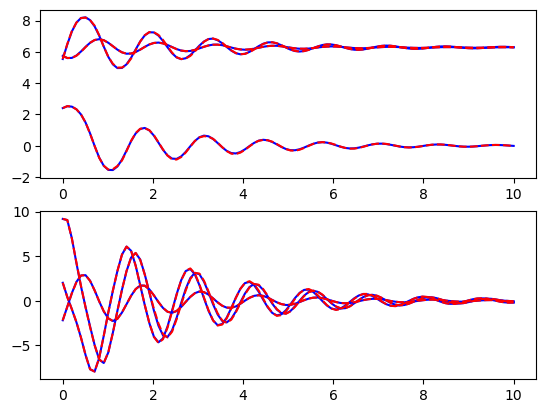

In [ ]:
with torch.no_grad():
    predicted_trajectories = model(y_0s, ts).permute(1, 0, 2).cpu().numpy()

fig, axs = plt.subplots(2)
for trajectory in trajectories_list:
    thetas, omegas = trajectory[:, 0].cpu().tolist(), trajectory[:, 1].tolist()
    axs[0].plot(ts, thetas, 'b')
    axs[1].plot(ts, omegas, 'b')

for predicted_trajectory in predicted_trajectories: 
    thetas, omegas = predicted_trajectory[:, 0].cpu().tolist(), predicted_trajectory[:, 1].tolist()
    axs[0].plot(ts, thetas, 'r--')
    axs[1].plot(ts, omegas, 'r--')




    